# 🧠 Laboratorio 4 – Latent Semantic Indexing with SVD

**Corso:** Information Retrieval – Laurea Magistrale in Informatica  
**Università:** Roma “Tor Vergata”  
**Docente:** Danilo Croce


Nel laboratorio precedente abbiamo studiato modelli probabilistici di ranking:

- BM25
- Language Models for IR

In questo laboratorio cambiamo prospettiva.

Partiamo dalla matrice termine-documento e usiamo una tecnica di algebra lineare,
la **Singular Value Decomposition** o **SVD**, per costruire una rappresentazione
latente di termini e documenti.

L'idea centrale del Latent Semantic Indexing è:

> parole e documenti che non condividono esattamente gli stessi termini possono comunque essere vicini in uno spazio semantico latente.

Per esempio, se nella collezione le parole `car` e `automobile` compaiono in documenti simili, allora una query con `automobile` può recuperare documenti vicini a `car`, anche quando non condividono tutti i termini esatti.

LSI cerca di catturare queste associazioni usando la struttura globale della matrice termine-documento.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

## Una mini-collezione didattica

Prima di usare una collezione reale, partiamo da una mini-collezione costruita a mano.

L'obiettivo è vedere chiaramente:

- la matrice termine-documento;
- la decomposizione SVD;
- la riduzione di rango;
- la rappresentazione latente di termini e documenti.

In [ ]:
documents = [
    "car truck engine road",
    "car engine wheel road",
    "truck engine highway",
    "cat dog animal",
    "dog animal pet",
    "cat car kitten"
]

doc_names = [f"d{i+1}" for i in range(len(documents))]

for name, text in zip(doc_names, documents):
    print(name, ":", text)

d1 : car truck engine road
d2 : car engine wheel road
d3 : truck engine highway
d4 : cat dog animal
d5 : dog animal pet
d6 : cat car kitten


## Costruzione della matrice termine-documento

Costruiamo una matrice $A$, dove:

- le righe sono termini;
- le colonne sono documenti;
- la cella $A_{t,d}$ contiene il peso del termine $t$ nel documento $d$.

Per iniziare usiamo pesi TF-IDF.

In [ ]:
vectorizer = TfidfVectorizer(norm=None, use_idf=True)
X = vectorizer.fit_transform(documents)

terms = vectorizer.get_feature_names_out()

# sklearn produce una matrice documenti x termini.
# Per coerenza con la teoria IR, trasponiamo:
# A = termini x documenti
A = X.toarray().T

A_df = pd.DataFrame(A, index=terms, columns=doc_names)
A_df

,d1,d2,d3,d4,d5,d6
animal,0.000000,0.000000,0.000000,1.847298,1.847298,0.000000
car,1.559616,1.559616,0.000000,0.000000,0.000000,1.559616
cat,0.000000,0.000000,0.000000,1.847298,0.000000,1.847298
dog,0.000000,0.000000,0.000000,1.847298,1.847298,0.000000
engine,1.559616,1.559616,1.559616,0.000000,0.000000,0.000000
highway,0.000000,0.000000,2.252763,0.000000,0.000000,0.000000
kitten,0.000000,0.000000,0.000000,0.000000,0.000000,2.252763
pet,0.000000,0.000000,0.000000,0.000000,2.252763,0.000000
road,1.847298,1.847298,0.000000,0.000000,0.000000,0.000000
truck,1.847298,0.000000,1.847298,0.000000,0.000000,0.000000


Ogni colonna è un documento.

Ogni riga è un termine.

Quindi un documento è rappresentato come un vettore nello spazio dei termini.

Per esempio, il documento $d_1$ è la prima colonna della matrice.

## Singular Value Decomposition

La SVD decompone la matrice termine-documento $A$ come:

$$
A = U \Sigma V^T
$$

dove:

- $U$ contiene i vettori latenti associati ai termini;
- $\Sigma$ contiene i valori singolari;
- $V^T$ contiene i vettori latenti associati ai documenti.

I valori singolari indicano quanta informazione è catturata da ciascuna dimensione latente.

In [ ]:
U, singular_values, Vt = np.linalg.svd(A, full_matrices=False)

print("Shape of A:", A.shape)
print("Shape of U:", U.shape)
print("Shape of singular values:", singular_values.shape)
print("Shape of Vt:", Vt.shape)

print("\nSingular values:")
print(singular_values)

Shape of A: (11, 6)
Shape of U: (11, 6)
Shape of singular values: (6,)
Shape of Vt: (6, 6)

Singular values:
[4.9316493  4.30363171 3.35868145 2.9544564  1.82490879 1.68434252]


## Quanta informazione catturano le componenti?

I valori singolari più grandi catturano le direzioni principali della matrice.

Possiamo misurare quanta "energia" viene spiegata dalle prime $k$ componenti usando:

$$
\frac{\sum_{i=1}^{k}\sigma_i^2}{\sum_i \sigma_i^2}
$$

In LSI manteniamo le direzioni associate ai valori singolari più grandi e scartiamo quelle associate ai valori più piccoli, interpretate come dettagli o rumore.

In [ ]:
energy = singular_values**2
explained_energy_ratio = energy / energy.sum()
cumulative_energy = np.cumsum(explained_energy_ratio)

energy_df = pd.DataFrame({
    "component": np.arange(1, len(singular_values) + 1),
    "singular_value": singular_values,
    "explained_energy_ratio": explained_energy_ratio,
    "cumulative_energy": cumulative_energy
})

energy_df

,component,singular_value,explained_energy_ratio,cumulative_energy
0,1,4.931649,0.352382,0.352382
1,2,4.303632,0.268349,0.620731
2,3,3.358681,0.163443,0.784175
3,4,2.954456,0.126469,0.910644
4,5,1.824909,0.048252,0.958895
5,6,1.684343,0.041105,1.000000


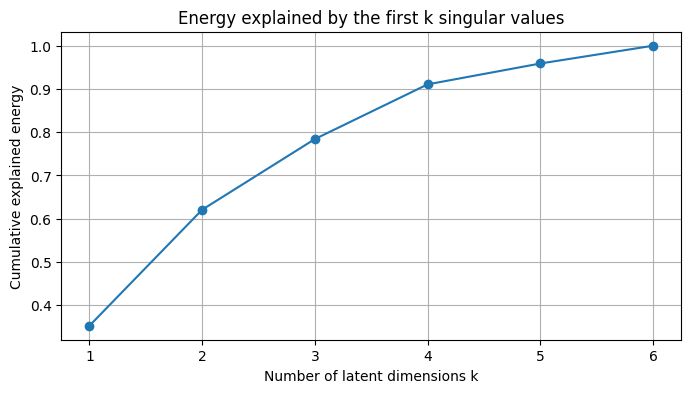

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(
    np.arange(1, len(cumulative_energy) + 1),
    cumulative_energy,
    marker="o"
)
plt.xlabel("Number of latent dimensions k")
plt.ylabel("Cumulative explained energy")
plt.title("Energy explained by the first k singular values")
plt.grid(True)
plt.show()

## Approssimazione a basso rango

LSI usa solo le prime $k$ componenti della SVD:

$$
A_k = U_k\Sigma_k V_k^T
$$

Questa matrice è una versione compressa di $A$.

Se $k$ è piccolo, perdiamo dettagli ma possiamo catturare la struttura semantica principale.

In [ ]:
def low_rank_approximation(U, singular_values, Vt, k):
    U_k = U[:, :k]
    S_k = np.diag(singular_values[:k])
    Vt_k = Vt[:k, :]
    return U_k @ S_k @ Vt_k

A_2 = low_rank_approximation(U, singular_values, Vt, k=2)

A_2_df = pd.DataFrame(A_2, index=terms, columns=doc_names)
A_2_df

,d1,d2,d3,d4,d5,d6
animal,-0.084826,-0.055289,-0.152079,1.685353,1.728008,0.667599
car,1.463450,1.431869,0.893516,0.264500,0.180839,0.604549
cat,0.227632,0.241117,0.072388,1.170430,1.182521,0.560602
dog,-0.084826,-0.055289,-0.152079,1.685353,1.728008,0.667599
engine,1.650793,1.609135,1.029742,-0.072043,-0.174647,0.528908
highway,0.571581,0.556351,0.359462,-0.074416,-0.111042,0.162693
kitten,0.300977,0.300303,0.162693,0.411697,0.402434,0.271952
pet,-0.080062,-0.061162,-0.111042,1.039640,1.067650,0.402434
road,1.486589,1.449735,0.924921,-0.024309,-0.115806,0.493058
truck,1.221385,1.190125,0.763469,-0.080196,-0.156708,0.380216


Confrontiamo la matrice originale $A$ con la sua approssimazione $A_2$.

Notiamo che $A_2$ non è identica ad $A$, ma introduce associazioni latenti.

Alcune celle che erano zero possono diventare leggermente positive o negative:
questo è il segnale che LSI sta ricostruendo relazioni indirette.

In [ ]:
print("Original matrix A:")
display(A_df.round(3))

print("Low-rank approximation A_2:")
display(A_2_df.round(3))

Original matrix A:


,d1,d2,d3,d4,d5,d6
animal,0.000,0.000,0.000,1.847,1.847,0.000
car,1.560,1.560,0.000,0.000,0.000,1.560
cat,0.000,0.000,0.000,1.847,0.000,1.847
dog,0.000,0.000,0.000,1.847,1.847,0.000
engine,1.560,1.560,1.560,0.000,0.000,0.000
highway,0.000,0.000,2.253,0.000,0.000,0.000
kitten,0.000,0.000,0.000,0.000,0.000,2.253
pet,0.000,0.000,0.000,0.000,2.253,0.000
road,1.847,1.847,0.000,0.000,0.000,0.000
truck,1.847,0.000,1.847,0.000,0.000,0.000


Low-rank approximation A_2:


,d1,d2,d3,d4,d5,d6
animal,-0.085,-0.055,-0.152,1.685,1.728,0.668
car,1.463,1.432,0.894,0.264,0.181,0.605
cat,0.228,0.241,0.072,1.170,1.183,0.561
dog,-0.085,-0.055,-0.152,1.685,1.728,0.668
engine,1.651,1.609,1.030,-0.072,-0.175,0.529
highway,0.572,0.556,0.359,-0.074,-0.111,0.163
kitten,0.301,0.300,0.163,0.412,0.402,0.272
pet,-0.080,-0.061,-0.111,1.040,1.068,0.402
road,1.487,1.450,0.925,-0.024,-0.116,0.493
truck,1.221,1.190,0.763,-0.080,-0.157,0.380


## Errore di ricostruzione

Più alto è $k$, più $A_k$ si avvicina ad $A$.

Misuriamo l'errore con la norma di Frobenius:

$$
\|A-A_k\|_F
$$

In [ ]:
errors = []

for k in range(1, len(singular_values) + 1):
    A_k = low_rank_approximation(U, singular_values, Vt, k)
    error = np.linalg.norm(A - A_k, ord="fro")
    errors.append((k, error))

errors_df = pd.DataFrame(errors, columns=["k", "reconstruction_error"])
errors_df

,k,reconstruction_error
0,1,6.685664e+00
1,2,5.116332e+00
2,3,3.859548e+00
3,4,2.483405e+00
4,5,1.684343e+00
5,6,1.113039e-14


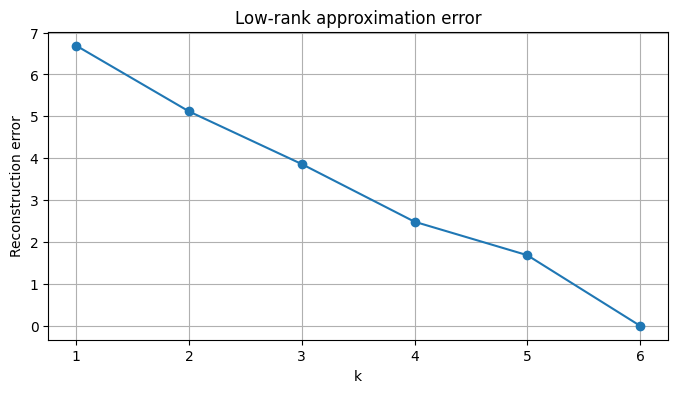

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(errors_df["k"], errors_df["reconstruction_error"], marker="o")
plt.xlabel("k")
plt.ylabel("Reconstruction error")
plt.title("Low-rank approximation error")
plt.grid(True)
plt.show()

## Documenti nello spazio latente

Con LSI, ogni documento viene rappresentato in uno spazio di dimensione $k$.

Dalla SVD:

$$
A_k = U_k\Sigma_k V_k^T
$$

Le coordinate dei documenti nello spazio latente sono spesso prese da:

$$
D_k = \Sigma_k V_k^T
$$

Le colonne di $D_k$ sono i vettori latenti dei documenti.

In [ ]:
k = 2

U_k = U[:, :k]
S_k = np.diag(singular_values[:k])
Vt_k = Vt[:k, :]

document_embeddings = S_k @ Vt_k

doc_emb_df = pd.DataFrame(
    document_embeddings.T,
    index=doc_names,
    columns=[f"latent_{i+1}" for i in range(k)]
)

doc_emb_df

,latent_1,latent_2
d1,-3.114356,0.400308
d2,-3.044545,0.343765
d3,-1.910909,0.417810
d4,-0.403055,-2.868166
d5,-0.221465,-2.956418
d6,-1.220503,-1.049513


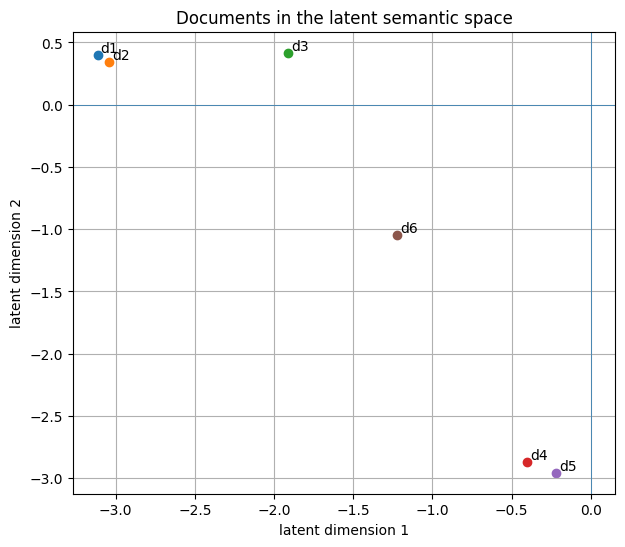

In [ ]:
plt.figure(figsize=(7, 6))

for doc_name in doc_names:
    x = doc_emb_df.loc[doc_name, "latent_1"]
    y = doc_emb_df.loc[doc_name, "latent_2"]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, doc_name)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel("latent dimension 1")
plt.ylabel("latent dimension 2")
plt.title("Documents in the latent semantic space")
plt.grid(True)
plt.show()

## Termini nello spazio latente

Anche i termini possono essere rappresentati nello spazio latente.

Una scelta comune è:

$$
T_k = U_k\Sigma_k
$$

Le righe di $T_k$ sono i vettori latenti dei termini.

In [ ]:
term_embeddings = U_k @ S_k

term_emb_df = pd.DataFrame(
    term_embeddings,
    index=terms,
    columns=[f"latent_{i+1}" for i in range(k)]
)

term_emb_df

,latent_1,latent_2
animal,-0.233933,-2.500154
car,-2.333709,-0.110690
cat,-0.608153,-1.681631
dog,-0.233933,-2.500154
engine,-2.552047,0.421061
highway,-0.872898,0.218705
kitten,-0.557522,-0.549374
pet,-0.101164,-1.547555
road,-2.307002,0.319387
truck,-1.882364,0.351170


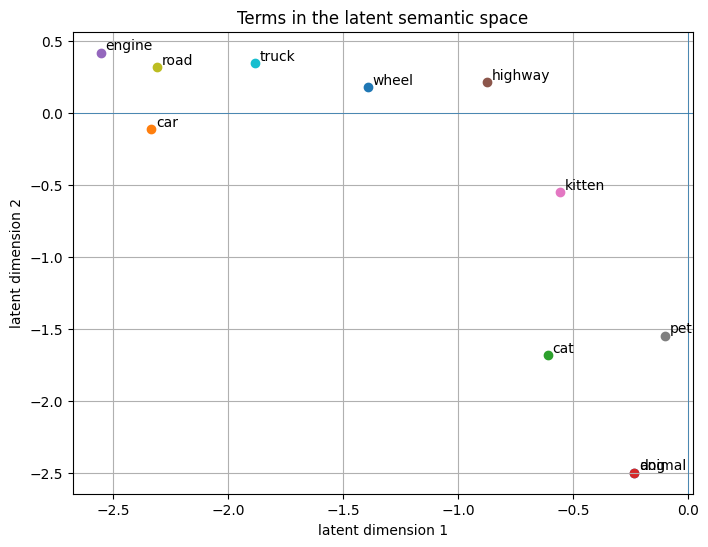

In [ ]:
plt.figure(figsize=(8, 6))

for term in terms:
    x = term_emb_df.loc[term, "latent_1"]
    y = term_emb_df.loc[term, "latent_2"]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, term)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel("latent dimension 1")
plt.ylabel("latent dimension 2")
plt.title("Terms in the latent semantic space")
plt.grid(True)
plt.show()

## Convenzioni per rappresentare termini, documenti e query

Esistono diverse convenzioni per rappresentare termini e documenti nello spazio latente.

Per il ranking documento-query è comune usare:

$$
D_k=\Sigma_k V_k^T
$$

Le colonne di \(D_k\) sono i vettori latenti dei documenti.

Con questa convenzione, una query \(q\), espressa nello spazio originale dei termini, viene proiettata nello spazio latente con:

$$
q_k=q^T U_k\Sigma_k^{-1}
$$

Questa operazione è chiamata **folding-in**.

Per interpretare invece una cella $A_k(t,d)$ come prodotto scalare tra vettore termine e vettore documento, è comoda la rappresentazione simmetrica:

$$
A_k =
(U_k\Sigma_k^{1/2})(\Sigma_k^{1/2}V_k^T)
$$

In questo caso definiamo:

$$
T_k=U_k\Sigma_k^{1/2}
$$

$$
D_k=\Sigma_k^{1/2}V_k^T
$$

e otteniamo:

$$
A_k(t,d)\approx \langle T_k(t),D_k(d)\rangle
$$

## Termini e documenti nello stesso spazio

Possiamo visualizzare termini e documenti nello stesso spazio latente.

Questo è uno degli aspetti più interessanti di LSI:
termini e documenti diventano punti nello stesso spazio semantico.

Tuttavia, per ottenere una rappresentazione simmetrica, possiamo dividere la matrice
dei valori singolari in due parti:

$$
A_k =
U_k\Sigma_k V_k^T
=
(U_k\Sigma_k^{1/2})(\Sigma_k^{1/2}V_k^T)
$$

Quindi definiamo:

$$
T_k = U_k\Sigma_k^{1/2}
$$

$$
D_k = \Sigma_k^{1/2}V_k^T
$$

Allora:

$$
A_k(t,d) \approx \langle T_k(t),D_k(d)\rangle
$$

cioè la cella termine-documento è ricostruita come prodotto scalare tra
il vettore latente del termine e il vettore latente del documento.

Le rappresentazioni $U_k\Sigma_k$ e $\Sigma_k V_k^T$ sono utili per visualizzare termini e documenti, ma per interpretare direttamente una cella $A_k(t,d)$ come prodotto scalare termine-documento è più naturale usare la rappresentazione simmetrica:

In [ ]:
S_sqrt_k = np.diag(np.sqrt(singular_values[:k]))

term_embeddings_symmetric = U_k @ S_sqrt_k
document_embeddings_symmetric = S_sqrt_k @ Vt_k

term_sym_df = pd.DataFrame(
    term_embeddings_symmetric,
    index=terms,
    columns=[f"latent_{i+1}" for i in range(k)]
)

doc_sym_df = pd.DataFrame(
    document_embeddings_symmetric.T,
    index=doc_names,
    columns=[f"latent_{i+1}" for i in range(k)]
)

display(term_sym_df)
display(doc_sym_df)

,latent_1,latent_2
animal,-0.105340,-1.205172
car,-1.050874,-0.053357
cat,-0.273852,-0.810612
dog,-0.105340,-1.205172
engine,-1.149192,0.202968
highway,-0.393068,0.105424
kitten,-0.251053,-0.264820
pet,-0.045555,-0.745983
road,-1.038848,0.153957
truck,-0.847632,0.169278


,latent_1,latent_2
d1,-1.402401,0.192964
d2,-1.370965,0.165708
d3,-0.860486,0.201401
d4,-0.181496,-1.382569
d5,-0.099726,-1.425110
d6,-0.549595,-0.505906


## Verifica: prodotto scalare termine-documento

Verifichiamo numericamente che:

$$
A_k(t,d) \approx \langle \vec t,\vec d\rangle
$$

dove:

$$
\vec t = U_k(t)\Sigma_k^{1/2}
$$

$$
\vec d = \Sigma_k^{1/2}V_k^T(d)
$$

In [ ]:
term = "car"
doc = "d1"

term_vector = term_sym_df.loc[term].values
doc_vector = doc_sym_df.loc[doc].values

dot_product = np.dot(term_vector, doc_vector)

term_index = list(terms).index(term)
doc_index = doc_names.index(doc)

reconstructed_value = A_2[term_index, doc_index]
original_value = A[term_index, doc_index]

print("Term:", term)
print("Document:", doc)
print("Original A[t,d]:", original_value)
print("Low-rank A_2[t,d]:", reconstructed_value)
print("Dot product in latent space:", dot_product)

Term: car
Document: d1
Original A[t,d]: 1.5596157879354227
Low-rank A_2[t,d]: 1.4634502994169205
Dot product in latent space: 1.4634502994169203


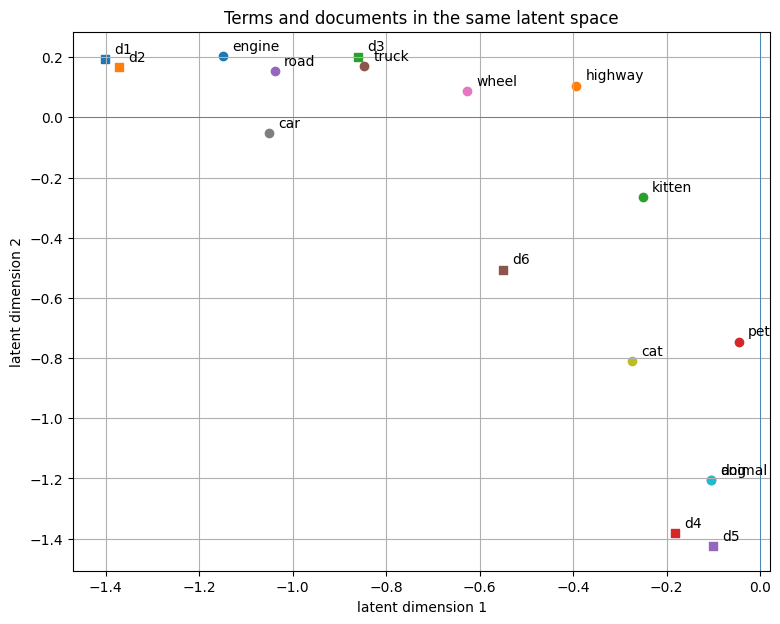

In [ ]:
plt.figure(figsize=(9, 7))

for doc_name in doc_names:
    x = doc_sym_df.loc[doc_name, "latent_1"]
    y = doc_sym_df.loc[doc_name, "latent_2"]
    plt.scatter(x, y, marker="s")
    plt.text(x + 0.02, y + 0.02, doc_name)

for term in terms:
    x = term_sym_df.loc[term, "latent_1"]
    y = term_sym_df.loc[term, "latent_2"]
    plt.scatter(x, y, marker="o")
    plt.text(x + 0.02, y + 0.02, term)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel("latent dimension 1")
plt.ylabel("latent dimension 2")
plt.title("Terms and documents in the same latent space")
plt.grid(True)
plt.show()

## Ranking nello spazio originale

Prima di usare LSI, calcoliamo il ranking con cosine similarity nello spazio TF-IDF originale.

In [ ]:
def rank_original_space(query, vectorizer, X, doc_names, documents, top_k=5):
    q_vec = vectorizer.transform([query])
    scores = cosine_similarity(q_vec, X).ravel()

    ranking = np.argsort(scores)[::-1][:top_k]

    rows = []
    for rank, doc_idx in enumerate(ranking, start=1):
        rows.append({
            "rank": rank,
            "doc": doc_names[doc_idx],
            "score": scores[doc_idx],
            "text": documents[doc_idx]
        })

    return pd.DataFrame(rows)

rank_original_space("car road", vectorizer, X, doc_names, documents)

,rank,doc,score,text
0,1,d1,0.707107,car truck engine road
1,2,d2,0.661625,car engine wheel road
2,3,d6,0.304465,cat car kitten
3,4,d5,0.000000,dog animal pet
4,5,d3,0.000000,truck engine highway


## Query folding-in

Ora vogliamo rappresentare una query nello spazio latente.

La query è inizialmente un vettore nello spazio dei termini.

Partiamo dall'approssimazione LSI:

$$
A_k = U_k\Sigma_k V_k^T
$$

Nel notebook rappresentiamo i documenti nello spazio latente usando:

$$
D_k = \Sigma_k V_k^T
$$

Le colonne di $D_k$ sono i vettori latenti dei documenti.

Con questa convenzione, una query \(q\), espressa nello spazio dei termini, viene proiettata nello spazio latente con:

$$
q_k = q^T U_k \Sigma_k^{-1}
$$

Questa operazione è chiamata folding-in.

L'idea è semplice:

- $q$ vive nello spazio originale dei termini;
- $U_k$ contiene le direzioni latenti principali nello spazio dei termini;
- moltiplicare $q^T$ per $U_k$ significa esprimere la query nelle coordinate latenti.

Dopo questa proiezione, possiamo confrontare la query latente $q_k$ con i documenti latenti usando cosine similarity.

Nel codice questo corrisponde a:

    q_k = q @ U_k @ np.linalg.inv(S_k)

e i documenti latenti sono ottenuti come:

    doc_k = (S_k @ Vt_k).T

Quindi lo score LSI viene calcolato confrontando:

$$
q_k
\qquad\text{con}\qquad
D_k(d)
$$

per ogni documento $d$.

In [ ]:
def fold_query_into_lsi_space(query, vectorizer, U_k, S_k):
    q = vectorizer.transform([query]).toarray()
    q_k = q @ U_k @ np.linalg.inv(S_k)
    return q_k


def rank_lsi(query, vectorizer, U_k, S_k, Vt_k, doc_names, documents, top_k=5):
    q_k = fold_query_into_lsi_space(query, vectorizer, U_k, S_k)

    doc_k = (S_k @ Vt_k).T

    scores = cosine_similarity(q_k, doc_k).ravel()
    ranking = np.argsort(scores)[::-1][:top_k]

    rows = []
    for rank, doc_idx in enumerate(ranking, start=1):
        rows.append({
            "rank": rank,
            "doc": doc_names[doc_idx],
            "score": scores[doc_idx],
            "text": documents[doc_idx]
        })

    return pd.DataFrame(rows)

## Confronto tra spazio originale e spazio LSI

Proviamo alcune query.

Osserviamo se LSI riesce a recuperare documenti semanticamente vicini anche quando non condividono esattamente gli stessi termini.

In [ ]:
queries = [
    "car road",
    "truck highway",
    "dog pet",
    "cat animal",
    "engine wheel",
]

for query in queries:
    print("=" * 80)
    print("QUERY:", query)
    print("=" * 80)

    print("\nOriginal TF-IDF space:")
    display(rank_original_space(query, vectorizer, X, doc_names, documents))

    print("\nLSI space:")
    display(rank_lsi(query, vectorizer, U_k, S_k, Vt_k, doc_names, documents))

QUERY: car road

Original TF-IDF space:


,rank,doc,score,text
0,1,d1,0.707107,car truck engine road
1,2,d2,0.661625,car engine wheel road
2,3,d6,0.304465,cat car kitten
3,4,d5,0.000000,dog animal pet
4,5,d3,0.000000,truck engine highway



LSI space:


,rank,doc,score,text
0,1,d2,0.999068,car engine wheel road
1,2,d1,0.998285,car truck engine road
2,3,d3,0.989360,truck engine highway
3,4,d6,0.711288,cat car kitten
4,5,d4,0.070302,cat dog animal


QUERY: truck highway

Original TF-IDF space:


...

,rank,doc,score,text
0,1,d4,0.999921,cat dog animal
1,2,d5,0.997007,dog animal pet
2,3,d6,0.759392,cat car kitten
3,4,d2,0.039717,car engine wheel road
4,5,d1,0.024326,car truck engine road


QUERY: engine wheel

Original TF-IDF space:


,rank,doc,score,text
0,1,d2,0.749835,car engine wheel road
1,2,d3,0.268648,truck engine highway
2,3,d1,0.259650,car truck engine road
3,4,d6,0.000000,cat car kitten
4,5,d5,0.000000,dog animal pet



LSI space:


,rank,doc,score,text
0,1,d3,0.999766,truck engine highway
1,2,d1,0.997838,car truck engine road
2,3,d2,0.996707,car engine wheel road
3,4,d6,0.618610,cat car kitten
4,5,d4,-0.053970,cat dog animal


# Esperimento su 20 Newsgroups

Ora passiamo a una collezione reale.

Useremo alcune categorie del dataset 20 Newsgroups.

L'obiettivo è osservare come LSI si comporta su testi più realistici.

In [ ]:
from datasets import load_dataset
import re

categories = [
    "comp.graphics",
    "rec.autos",
    "sci.space",
    "talk.politics.misc"
]

dataset = load_dataset("SetFit/20_newsgroups", split="train")

filtered_dataset = dataset.filter(
    lambda example: example["label_text"] in categories
)

def remove_newsgroup_header(text):
    parts = text.split("\n\n", 1)
    if len(parts) == 2:
        return parts[1]
    return text

def count_words(text):
    return len(re.findall(r"\b\w+\b", text))

min_words = 5

real_documents = []
real_labels_text = []

for text, label in zip(filtered_dataset["text"], filtered_dataset["label_text"]):
    cleaned_text = text

    if count_words(cleaned_text) >= min_words:
        real_documents.append(cleaned_text)
        real_labels_text.append(label)

target_names = sorted(set(real_labels_text))
label_to_id = {label: i for i, label in enumerate(target_names)}
real_labels = [label_to_id[label] for label in real_labels_text]

print("Number of documents:", len(real_documents))
print("Categories:", target_names)
print("First document:")
print(real_documents[0][:1000])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11314 [00:00<?, ? examples/s]

Number of documents: 2141
Categories: ['comp.graphics', 'rec.autos', 'sci.space', 'talk.politics.misc']
First document:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


## Un vectorizer più ricco per analizzare i termini

Per il ranking TF-IDF e LSI possiamo usare un vocabolario relativamente piccolo, ad esempio 5000 termini, così il notebook rimane leggero.

Però, quando vogliamo cercare i **termini vicini nello spazio LSI**, un vocabolario troppo piccolo può essere limitante: molte parole interessanti potrebbero non essere presenti.

Per questo costruiamo un secondo vectorizer, pensato non tanto per il ranking dei documenti, ma per l'analisi delle relazioni tra termini.

Useremo una matrice TF-IDF con queste scelte:

- `stop_words="english"`: rimuove parole molto comuni come `the`, `and`, `of`;
- `max_df=0.9`: elimina termini che compaiono in più del 90% dei documenti;
- `min_df=3`: elimina termini che compaiono in meno di 3 documenti;
- `max_features=5000`: mantiene al massimo 5000 termini;
- `sublinear_tf=True`: usa una crescita logaritmica della term frequency;
- `norm=None`: non normalizza i vettori documento prima della SVD.

La scelta `sublinear_tf=True` significa che il peso della frequenza non cresce linearmente con il numero di occorrenze, ma in modo logaritmico:

$$
tf \quad \longrightarrow \quad 1+\log(tf)
$$

Questa scelta riduce l'effetto delle ripetizioni molto alte, in modo simile all'intuizione già vista con BM25: più occorrenze aiutano, ma con rendimento decrescente.

La scelta `norm=None` è utile perché vogliamo applicare la SVD alla matrice TF-IDF pesata senza imporre prima una normalizzazione L2 dei documenti.

In sintesi, questo vectorizer produce una matrice più ricca e adatta a costruire embedding latenti dei termini.

In [ ]:
real_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=3,
    max_features=5000,
    sublinear_tf=True,
    norm=None
)

X_real = real_vectorizer.fit_transform(real_documents)

print("Shape of TF-IDF matrix:", X_real.shape)

Shape of TF-IDF matrix: (2141, 5000)


**Nota importante**: nella mini-collezione abbiamo trasposto la matrice per seguire la convenzione teorica termini × documenti.

Nella parte con scikit-learn usiamo invece la convenzione standard documenti × termini, perché TruncatedSVD lavora direttamente sulla matrice prodotta da TfidfVectorizer.

Le formule sono equivalenti a trasposizione, ma bisogna stare attenti all'interpretazione di U e V.

## Truncated SVD

Su una collezione reale la matrice può essere grande.

Usiamo quindi `TruncatedSVD`, che calcola solo le prime \(k\) componenti.

In [ ]:
k = 100

svd = TruncatedSVD(n_components=k, random_state=42)
X_lsi = svd.fit_transform(X_real)

print("Original shape:", X_real.shape)
print("LSI shape:", X_lsi.shape)

print("Explained variance ratio:", svd.explained_variance_ratio_.sum())

Original shape: (2141, 5000)
LSI shape: (2141, 100)
Explained variance ratio: 0.5513231671550437


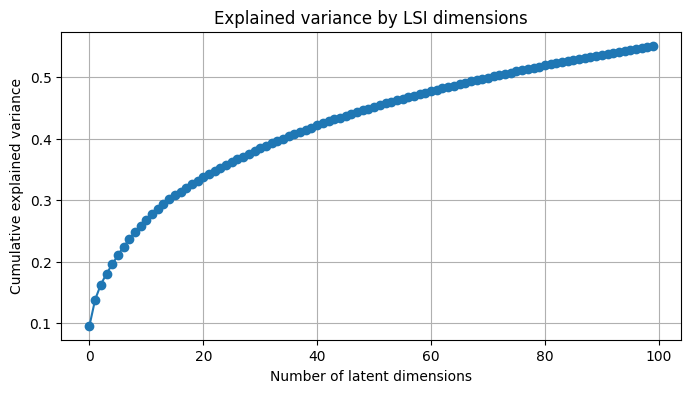

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker="o")
plt.xlabel("Number of latent dimensions")
plt.ylabel("Cumulative explained variance")
plt.title("Explained variance by LSI dimensions")
plt.grid(True)
plt.show()

In [ ]:
def rank_tfidf_real(query, top_k=10):
    q = real_vectorizer.transform([query])
    scores = cosine_similarity(q, X_real).ravel()
    ranking = np.argsort(scores)[::-1][:top_k]

    rows = []
    for rank, idx in enumerate(ranking, start=1):
        rows.append({
            "rank": rank,
            "doc_id": idx,
            "score": scores[idx],
            "category": target_names[real_labels[idx]],
            "preview": real_documents[idx][:300].replace("\n", " ")
        })

    return pd.DataFrame(rows)


def rank_lsi_real(query, top_k=10):
    q = real_vectorizer.transform([query])
    q_lsi = svd.transform(q)

    scores = cosine_similarity(q_lsi, X_lsi).ravel()
    ranking = np.argsort(scores)[::-1][:top_k]

    rows = []
    for rank, idx in enumerate(ranking, start=1):
        rows.append({
            "rank": rank,
            "doc_id": idx,
            "score": scores[idx],
            "category": target_names[real_labels[idx]],
            "preview": real_documents[idx][:300].replace("\n", " ")
        })

    return pd.DataFrame(rows)

In [ ]:
query = "space shuttle orbit nasa"

print("TF-IDF ranking")
display(rank_tfidf_real(query, top_k=10))

print("LSI ranking")
display(rank_lsi_real(query, top_k=10))

TF-IDF ranking


,rank,doc_id,score,category,preview
0,1,545,0.292541,sci.space,Better idea for use of NASA Shuttle Astronaut...
1,2,544,0.291913,sci.space,"Hello everyone, \tI was hoping someone could ..."
2,3,819,0.283684,sci.space,I am coordinating the Space Shuttle Program Of...
3,4,305,0.270679,sci.space,"For an essay, I am writing about the space shu..."
4,5,1861,0.262949,sci.space,Is it right??? That is new stuff for me. So i...
5,6,793,0.239691,sci.space,There is a guy in NASA Johnson Space Center t...
6,7,1265,0.238207,sci.space,: Has anyone ever heard of a food product call...
7,8,1904,0.236498,sci.space,I have 19 (2 MB worth!) uuencode'd GIF images ...
8,9,1590,0.234504,sci.space,: Announce that a reward of $1 billion would g...
9,10,457,0.225934,sci.space,I am looking for any information about the spa...


LSI ranking


,rank,doc_id,score,category,preview
0,1,819,0.810339,sci.space,I am coordinating the Space Shuttle Program Of...
1,2,1265,0.802548,sci.space,: Has anyone ever heard of a food product call...
2,3,793,0.783227,sci.space,There is a guy in NASA Johnson Space Center t...
3,4,1590,0.751453,sci.space,: Announce that a reward of $1 billion would g...
4,5,283,0.713838,sci.space,Portuguese launch complex??? Gosh.... Polish ...
5,6,305,0.713060,sci.space,"For an essay, I am writing about the space shu..."
6,7,1919,0.700381,sci.space,: >There is an emergency oxygen system that i...
7,8,1727,0.686723,sci.space,Seems that the Mile-Long Billboard and any oth...
8,9,545,0.662596,sci.space,Better idea for use of NASA Shuttle Astronaut...
9,10,1904,0.653462,sci.space,I have 19 (2 MB worth!) uuencode'd GIF images ...


In [ ]:
queries = [
    "space shuttle orbit nasa",
    "car engine road",
    "computer graphics image rendering",
    "government political debate",
]

for query in queries:
    print("=" * 100)
    print("QUERY:", query)
    print("=" * 100)

    print("\nTF-IDF")
    display(rank_tfidf_real(query, top_k=5))

    print("\nLSI")
    display(rank_lsi_real(query, top_k=5))

QUERY: space shuttle orbit nasa

TF-IDF


,rank,doc_id,score,category,preview
0,1,545,0.292541,sci.space,Better idea for use of NASA Shuttle Astronaut...
1,2,544,0.291913,sci.space,"Hello everyone, \tI was hoping someone could ..."
2,3,819,0.283684,sci.space,I am coordinating the Space Shuttle Program Of...
3,4,305,0.270679,sci.space,"For an essay, I am writing about the space shu..."
4,5,1861,0.262949,sci.space,Is it right??? That is new stuff for me. So i...



LSI


,rank,doc_id,score,category,preview
0,1,819,0.810339,sci.space,I am coordinating the Space Shuttle Program Of...
1,2,1265,0.802548,sci.space,: Has anyone ever heard of a food product call...
2,3,793,0.783227,sci.space,There is a guy in NASA Johnson Space Center t...
3,4,1590,0.751453,sci.space,: Announce that a reward of $1 billion would g...
4,5,283,0.713838,sci.space,Portuguese launch complex??? Gosh.... Polish ...


QUERY: car engine road

TF-IDF


...

,rank,doc_id,score,category,preview
0,1,564,0.722195,comp.graphics,I'm interested in find out what is involved in...
1,2,1489,0.706629,comp.graphics,"Hello, I am searching for rendering softw..."
2,3,1005,0.684925,comp.graphics,My package is based on several articles about...
3,4,516,0.672476,comp.graphics,"\tYes, that's known as ""Bresenhams Run Length..."
4,5,2053,0.669574,comp.graphics,We have been shipping for over one year the Ad...


QUERY: government political debate

TF-IDF


,rank,doc_id,score,category,preview
0,1,2118,0.198527,talk.politics.misc,I am so tired about all this debate on how man...
1,2,554,0.181654,talk.politics.misc,The speed limit on commuter tracks in the nor...
2,3,1244,0.160465,talk.politics.misc,"Excellently put! Even as a libertarian, I ha..."
3,4,239,0.154604,talk.politics.misc,The economic and political ignorance of most ...
4,5,353,0.152570,talk.politics.misc,This is a difficult problem for which there ...



LSI


,rank,doc_id,score,category,preview
0,1,1244,0.691899,talk.politics.misc,"Excellently put! Even as a libertarian, I ha..."
1,2,353,0.678532,talk.politics.misc,This is a difficult problem for which there ...
2,3,1352,0.614994,talk.politics.misc,\t\t [Patrick's example of anti-competitive...
3,4,751,0.608253,talk.politics.misc,"Of course, one again faces the question of ho..."
4,5,1326,0.605539,talk.politics.misc,Either the government has force available to...


## Effetto del numero di dimensioni latenti $k$

Il parametro $k$ controlla la dimensionalità dello spazio latente.

- $k$ troppo piccolo: perdiamo troppa informazione;
- $k$ troppo grande: ci avviciniamo allo spazio originale e manteniamo più rumore;
- $k$ intermedio: possiamo ottenere una buona rappresentazione semantica compressa.

In [ ]:
def build_lsi_model(k):
    model = TruncatedSVD(n_components=k, random_state=42)
    X_lsi_k = model.fit_transform(X_real)
    return model, X_lsi_k


def rank_lsi_with_model(query, model, X_lsi_k, top_k=5):
    q = real_vectorizer.transform([query])
    q_lsi = model.transform(q)

    scores = cosine_similarity(q_lsi, X_lsi_k).ravel()
    ranking = np.argsort(scores)[::-1][:top_k]

    rows = []
    for rank, idx in enumerate(ranking, start=1):
        rows.append({
            "rank": rank,
            "doc_id": idx,
            "score": scores[idx],
            "category": target_names[real_labels[idx]],
            "preview": real_documents[idx][:220].replace("\n", " ")
        })

    return pd.DataFrame(rows)

In [ ]:
query = "computer graphics image rendering"

for k_value in [2, 5, 20, 50, 100, 200]:
    print("=" * 100)
    print("k =", k_value)
    print("=" * 100)

    model_k, X_lsi_k = build_lsi_model(k_value)
    print("Explained variance:", model_k.explained_variance_ratio_.sum())

    display(rank_lsi_with_model(query, model_k, X_lsi_k, top_k=5))

k = 2
Explained variance: 0.13824731216348132


,rank,doc_id,score,category,preview
0,1,383,1.000000,comp.graphics,Another source: There's a poly blitter for m...
1,2,1222,0.999912,comp.graphics,PPPPP OOOOO V V Persistance Of Visio...
2,3,1431,0.999897,comp.graphics,xgif is the grandfather of XV. --
3,4,1913,0.999881,comp.graphics,There is a library of map projections in: ...
4,5,998,0.999857,comp.graphics,Has anybody made a converter from irit's .irt ...


k = 5
Explained variance: 0.19547421316509575


,rank,doc_id,score,category,preview
0,1,383,0.999254,comp.graphics,Another source: There's a poly blitter for m...
1,2,2037,0.991622,comp.graphics,"Is the "".3ds"" file format for Autodesk's 3D An..."
2,3,1929,0.989097,comp.graphics,"Hi, well I have opened up a FTP site for gett..."
3,4,312,0.982284,comp.graphics,Hi. The RTrace ray tracer supports 3D text as...
4,5,1061,0.982225,comp.graphics,There is a new version of the RTrace ray-traci...


k = 20
Explained variance: 0.3314788421128693


...

,rank,doc_id,score,category,preview
0,1,564,0.768809,comp.graphics,I'm interested in find out what is involved in...
1,2,2037,0.742664,comp.graphics,"Is the "".3ds"" file format for Autodesk's 3D An..."
2,3,1005,0.725835,comp.graphics,My package is based on several articles about...
3,4,1703,0.725391,comp.graphics,"Hi Netters, I'm building a CAD package and ne..."
4,5,1213,0.725263,comp.graphics,"Hello, I've been trying to bump map a gif on..."


k = 100
Explained variance: 0.5513231671550437


,rank,doc_id,score,category,preview
0,1,564,0.722195,comp.graphics,I'm interested in find out what is involved in...
1,2,1489,0.706629,comp.graphics,"Hello, I am searching for rendering softw..."
2,3,1005,0.684925,comp.graphics,My package is based on several articles about...
3,4,516,0.672476,comp.graphics,"\tYes, that's known as ""Bresenhams Run Length..."
4,5,2053,0.669574,comp.graphics,We have been shipping for over one year the Ad...


k = 200
Explained variance: 0.6715252499937965


,rank,doc_id,score,category,preview
0,1,516,0.657677,comp.graphics,"\tYes, that's known as ""Bresenhams Run Length..."
1,2,1005,0.616308,comp.graphics,My package is based on several articles about...
2,3,344,0.612401,comp.graphics,"I usually use ""Algorithms for graphics and im..."
3,4,685,0.610240,comp.graphics,"Graeme> \tYes, that's known as ""Bresenhams Ru..."
4,5,1454,0.561397,comp.graphics,"This sounds wonderful, but it seems no one ei..."


In [ ]:
def show_document(doc_id, max_chars=None):
    print("=" * 100)
    print("doc_id:", doc_id)
    print("category:", target_names[real_labels[doc_id]])
    print("=" * 100)

    text = real_documents[doc_id]

    if max_chars is not None:
        text = text[:max_chars]

    print(text)

In [ ]:
results_k = rank_lsi_with_model(query, model_k, X_lsi_k, top_k=5)

top_doc_id = int(results_k.iloc[0]["doc_id"])

show_document(top_doc_id, max_chars=1200)

doc_id: 516
category: comp.graphics

	Yes, that's known as "Bresenhams Run Length Slice Algorithm for
Incremental lines". See Fundamental Algorithms for Computer Graphics,
Springer-Verlag, Berlin Heidelberg 1985.


	Hmm. I don't think I can help you with this, but you might
take a look at the following:

	"Double-Step Incremental Generation of Lines and Circles",
X. Wu and J. G. Rokne, Computer Graphics and Image processing,
Vol 37, No. 4, Mar. 1987, pp. 331-334

	"Double-Step Generation of Ellipses", X. Wu and J. G. Rokne,
IEEE Computer Graphics & Applications, May 1989, pp. 56-69


## Parole vicine nello spazio latente

Finora abbiamo rappresentato i documenti nello spazio latente.

Ma LSI permette anche di rappresentare i termini nello stesso tipo di spazio.

L'idea è questa:

- nello spazio originale, due parole sono simili se compaiono negli stessi documenti;
- nello spazio latente, due parole sono simili se hanno comportamenti simili rispetto ai principali pattern della collezione.

Quindi possiamo fare una domanda molto naturale:

> quali parole sono più vicine a una parola data nello spazio LSI?

Per esempio, se cerchiamo le parole più vicine a `car`, ci aspettiamo parole come `engine`, `cars`, `road`, `auto`, `vehicle`.

Questo rende visibile l'effetto di LSI:

\[
\text{similarità lessicale diretta}
\longrightarrow
\text{similarità latente}
\]

Useremo una matrice più grande e un valore di \(k\) maggiore, perché con solo 2 dimensioni latenti perdiamo troppa informazione.

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

def build_term_embeddings_lsi(svd_model, vectorizer):
    """
    Costruisce embedding latenti per i termini usando un modello TruncatedSVD.

    Se X ≈ U Σ V^T, sklearn memorizza V^T in svd.components_.

    components_ ha shape:
        k x vocabulary_size

    Per ottenere i vettori dei termini:
        vocabulary_size x k

    usiamo:
        V_k Σ_k
    """
    terms = vectorizer.get_feature_names_out()

    # V_k: vocabulary_size x k
    V_k = svd_model.components_.T

    # Σ_k
    S_k = svd_model.singular_values_

    # Term embeddings: V_k Σ_k
    term_embeddings = V_k * S_k

    return terms, term_embeddings

In [ ]:
def nearest_terms(term, terms, term_embeddings, top_n=10):
    """
    Trova i termini più vicini a un termine nello spazio latente LSI.
    """
    term_to_index = {t: i for i, t in enumerate(terms)}

    if term not in term_to_index:
        print(f"Term '{term}' not found in vocabulary.")
        return pd.DataFrame()

    term_idx = term_to_index[term]

    query_vec = term_embeddings[term_idx].reshape(1, -1)

    similarities = cosine_similarity(query_vec, term_embeddings).ravel()

    ranking = np.argsort(similarities)[::-1]

    rows = []

    for idx in ranking:
        if terms[idx] == term:
            continue

        rows.append({
            "term": terms[idx],
            "similarity": similarities[idx]
        })

        if len(rows) >= top_n:
            break

    return pd.DataFrame(rows)

In [ ]:
k = 200

svd_terms_200 = TruncatedSVD(n_components=k, random_state=42)
X_lsi_200 = svd_terms_200.fit_transform(X_real)

terms_200, term_embeddings_200 = build_term_embeddings_lsi(
    svd_terms_200,
    real_vectorizer
)

print("Number of terms:", len(terms_200))
print("Term embedding shape:", term_embeddings_200.shape)

Number of terms: 5000
Term embedding shape: (5000, 200)


In [ ]:
nearest_terms("car", terms_200, term_embeddings_200, top_n=15)

,term,similarity
0,cars,0.686100
1,dealer,0.674565
2,wax,0.581415
3,rust,0.580651
4,odometer,0.560469
5,chevy,0.545046
6,volvo,0.522367
7,honda,0.496280
8,driving,0.493998
9,ford,0.484382


In [ ]:
nearest_terms("space", terms_200, term_embeddings_200, top_n=15)

,term,similarity
0,nasa,0.707830
1,shuttle,0.670859
2,technology,0.611678
3,launch,0.603924
4,science,0.592442
5,station,0.590248
6,earth,0.582334
7,orbit,0.582251
8,exploration,0.580969
9,modified,0.541207


In [ ]:
nearest_terms("government", terms_200, term_embeddings_200, top_n=15)

,term,similarity
0,political,0.568554
1,libertarian,0.557081
2,libertarianism,0.513322
3,people,0.479542
4,economic,0.463127
5,regulation,0.461671
6,private,0.461552
7,economy,0.460445
8,seven,0.454523
9,countries,0.449930


## Uso dei termini vicini per query expansion

I termini vicini nello spazio LSI possono essere usati anche per fare **query expansion**.

Per esempio, se la query contiene `space` e nello spazio latente troviamo termini vicini come `orbit`, `nasa`, `shuttle`, `mission`, `launch`, possiamo costruire una query espansa aggiungendo alcuni di questi termini.

L’idea è che i termini originali rappresentano ciò che l’utente ha scritto esplicitamente, mentre i termini espansi rappresentano associazioni latenti suggerite dalla collezione.

In pratica, i termini aggiunti dovrebbero avere un peso minore rispetto ai termini originali della query, perché possono aumentare il recall ma anche introdurre rumore.

## Perché non usare direttamente i vettori per tutto?

In teoria potremmo rappresentare query e documenti nello spazio LSI e calcolare la similarità della query con tutti i documenti.

Questo però può diventare costoso su collezioni molto grandi.

Se abbiamo milioni o miliardi di documenti, confrontare la query con tutti i vettori documento non è sempre pratico.

Per questo molti sistemi di retrieval usano una strategia a due fasi.

Nella prima fase, detta **candidate generation**, si usa un indice inverso per recuperare rapidamente un insieme piccolo di documenti candidati.

Nella seconda fase, detta **reranking**, si applica uno score più costoso solo sui candidati selezionati.

La query expansion può aiutare nella prima fase: aggiunge termini semanticamente vicini, permette all’indice inverso di recuperare documenti che non contengono esattamente i termini originali, e mantiene comunque efficiente la ricerca perché si continua a usare posting list invece di confrontare la query con tutti i vettori della collezione.

Quindi i vettori latenti sono utili in due modi: possono essere usati direttamente per fare ranking nello spazio LSI, oppure possono suggerire termini di espansione da usare dentro un sistema basato su indice inverso.

Nel secondo caso, LSI non sostituisce l’indice inverso: lo aiuta a recuperare candidati migliori.

# Esercizi finali

## Esercizio 1 — Interpretare la mini-collezione

Usa la mini-collezione iniziale.

1. Osserva la matrice termine-documento originale.
2. Osserva la matrice approssimata $A_2$.
3. Quali termini finiscono vicini nello spazio latente?
4. I documenti sugli animali e quelli sui veicoli vengono separati?

---

## Esercizio 2 — Cambiare $k$

Nella mini-collezione prova:

$$
k=1,\ 2,\ 3,\ 4
$$

Domande:

1. Come cambia l'errore di ricostruzione?
2. Come cambia il plot dei documenti?
3. Con $k=1$, quali informazioni vengono perse?
4. Con $k$ massimo, cosa succede?

---

## Esercizio 3 — Confrontare TF-IDF e LSI

Sulla collezione reale prova query come:

- `space mission orbit`
- `car engine speed`
- `image rendering graphics`
- `political government law`

Per ogni query confronta:

1. top-5 con TF-IDF;
2. top-5 con LSI;
3. categorie dei documenti recuperati;
4. documenti comuni ai due ranking.



## Take-away

LSI parte dalla matrice termine-documento e ne costruisce una approssimazione a basso rango:

$$
A_k = U_k \Sigma_k V_k^T
$$

Questa approssimazione elimina parte del rumore lessicale e conserva le principali associazioni tra termini e documenti.

Rispetto a TF-IDF:

- TF-IDF confronta documenti e query nello spazio originale dei termini;
- LSI li confronta in uno spazio latente di dimensione $k$;
- termini diversi possono risultare vicini se compaiono in contesti simili;
- il parametro $k$ controlla il compromesso tra compressione e perdita di informazione.

LSI non comprende il significato come un modello linguistico moderno, ma usa la struttura globale della matrice termine-documento per catturare associazioni latenti.

## Nota finale: LSI non è un modello neurale

LSI produce rappresentazioni dense di termini e documenti, ma non è un modello neurale.

Queste rappresentazioni non sono il risultato di un addestramento predittivo su un task, come avviene in word2vec, BERT o nei modelli transformer.

Sono invece ottenute tramite una decomposizione matriciale della matrice termine-documento.

Quindi la “semantica” catturata da LSI deriva dalla struttura globale delle co-occorrenze tra termini e documenti nella collezione.